Pizza businesses generate a large amount of sales data, but without proper analysis it is difficult to understand which pizzas are most popular, which sizes customers prefer, and how sales change across different months.

The objective of this project is to analyze pizza sales data to identify sales trends, customer preferences, and high-performing products. By using data analysis and visualization techniques, this project aims to provide insights that can help pizza businesses optimize their sales strategy and improve decision-making.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/pizza_sales (1).csv')

In [ ]:
df.head()


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [ ]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [ ]:
df.shape

(48620, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [ ]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [ ]:
df.isnull().sum()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


In [ ]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [ ]:
pizza_sales = df.groupby('pizza_name')["quantity"].sum()
pizza_sales

,quantity
pizza_name,
The Barbecue Chicken Pizza,2432
The Big Meat Pizza,1914
The Brie Carre Pizza,490
The Calabrese Pizza,937
The California Chicken Pizza,2370
The Chicken Alfredo Pizza,987
The Chicken Pesto Pizza,973
The Classic Deluxe Pizza,2453
The Five Cheese Pizza,1409


/tmp/ipykernel_312/652230738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pizza_sales.index, y=pizza_sales.values,palette="magma")


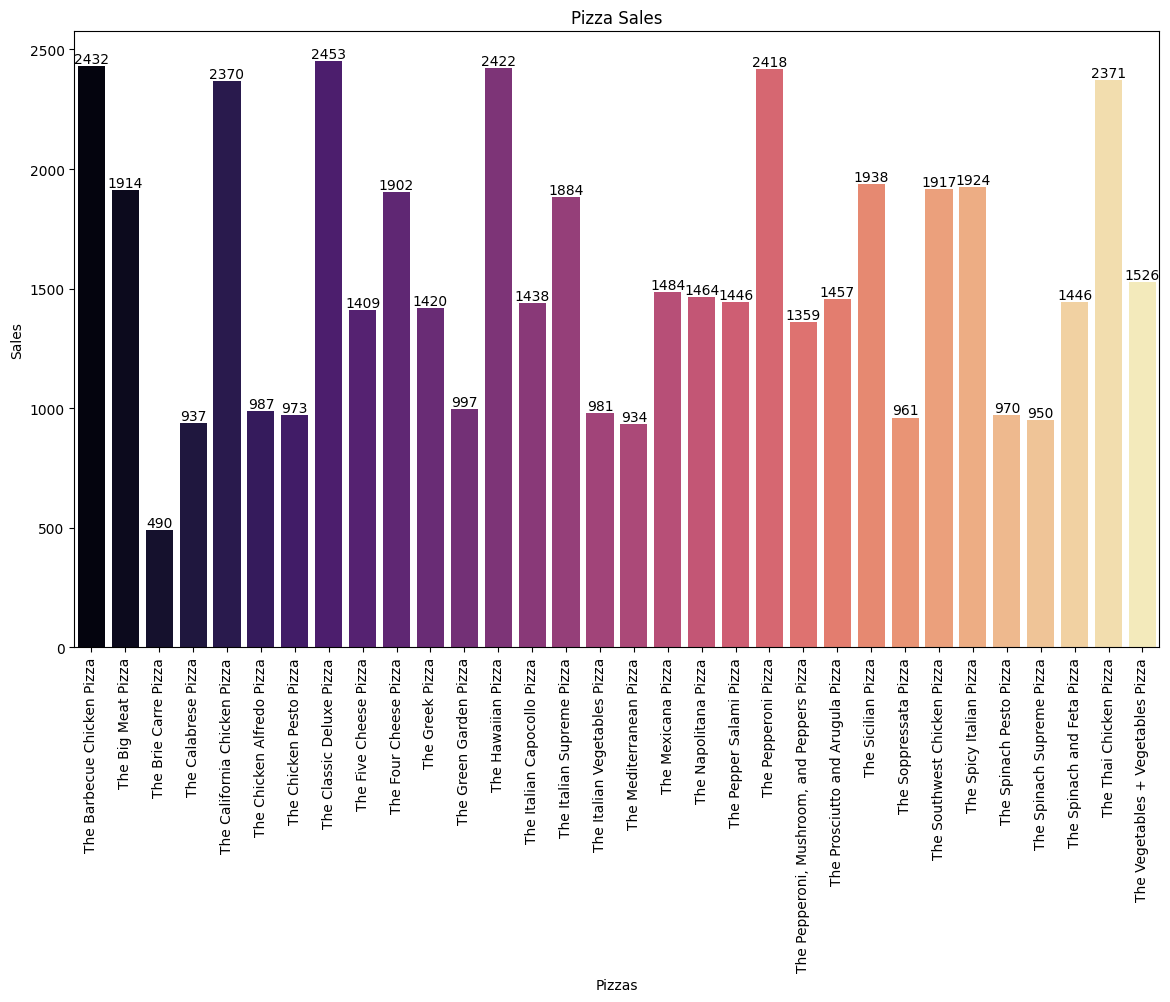

In [ ]:
plt.figure(figsize=(14,8))
ax = sns.barplot(x=pizza_sales.index, y=pizza_sales.values,palette="magma")
plt.xticks(rotation = 90)
plt.title('Pizza Sales')
plt.xlabel('Pizzas')
plt.ylabel('Sales')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Conclusion (Pizza Sales by Pizza Type):

Some pizzas show significantly higher sales compared to others.

Classic Deluxe Pizza and Barbecue Chicken Pizza are among the top-selling pizzas.

Many pizzas have moderate sales levels, indicating consistent customer demand.

A few pizzas such as Brie Carre Pizza and some specialty pizzas have very low sales, meaning they are less popular.

In [ ]:
pizza_category=df.groupby('pizza_category')["quantity"].sum()
pizza_category


,quantity
pizza_category,
Chicken,11050
Classic,14888
Supreme,11987
Veggie,11649


In [ ]:
top_pizzas = df.groupby('pizza_name')['quantity'].sum().nlargest(2).index
top_pizzas

df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')

monthly_sales = df[df['pizza_name'].isin(top_pizzas)] \
    .groupby([df['order_date'].dt.month, 'pizza_name'])['quantity'] \
    .sum().unstack()

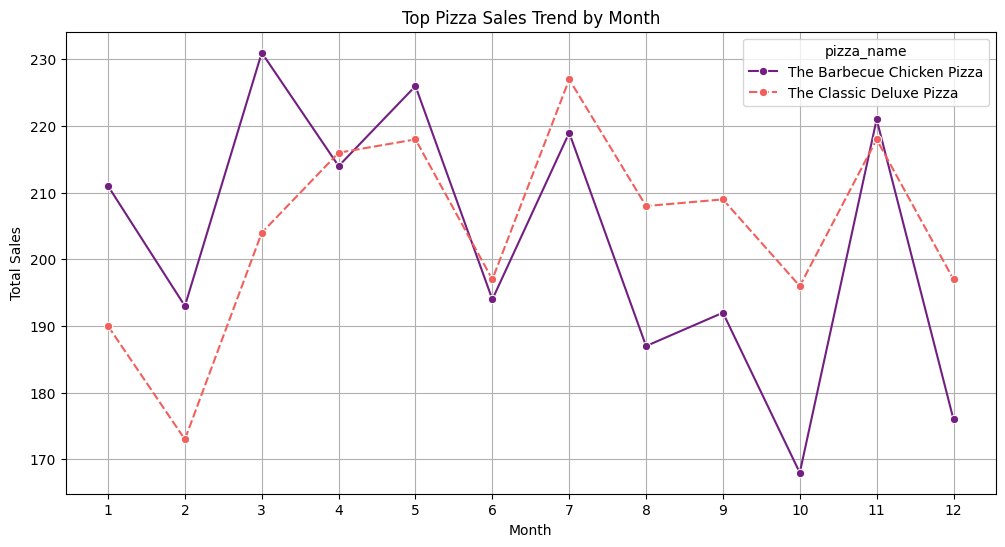

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(data=monthly_sales, marker="o", palette="magma")

plt.title("Top Pizza Sales Trend by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

Conclusion (Top Pizza Sales Trend by Month):

The Barbecue Chicken Pizza and Classic Deluxe Pizza both show fluctuating sales throughout the year.

Classic Deluxe Pizza generally maintains slightly more stable sales across most months.

Barbecue Chicken Pizza reaches high sales in some months but also shows sharper drops in others.

Both pizzas show strong performance around mid-year months (especially July).

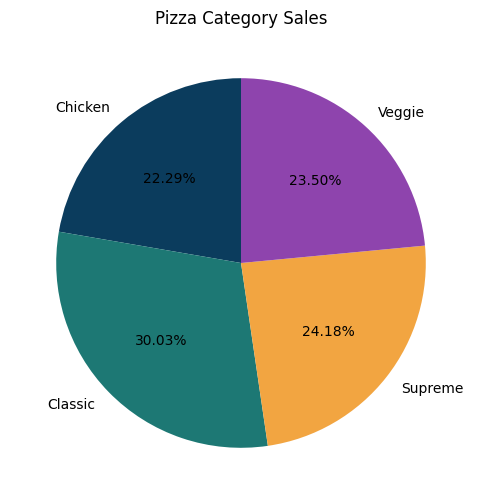

In [ ]:

pizza_category = df.groupby('pizza_category')["quantity"].sum()

plt.figure(figsize=(10,6))

colors = ["#0B3C5D", "#1D7874", "#F2A541", "#8E44AD"]   # premium colors

plt.pie(
    pizza_category.values,
    labels=pizza_category.index,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90
)

plt.title("Pizza Category Sales")
plt.show()

Conclusion (Pizza Category Sales):

Classic pizzas have the highest sales (30.03%), making them the most popular category among customers.

Supreme (24.18%) and Veggie (23.50%) pizzas have moderate and almost similar sales.

Chicken pizzas have the lowest sales (22.29%) among the four categories.

In [ ]:
pizza_size = df.groupby('pizza_size')["quantity"].sum()
pizza_size

,quantity
pizza_size,
L,18956
M,15635
S,14403
XL,552
XXL,28


/tmp/ipykernel_312/1071355593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.barplot(x=pizza_size.index,y=pizza_size.values,palette="inferno")


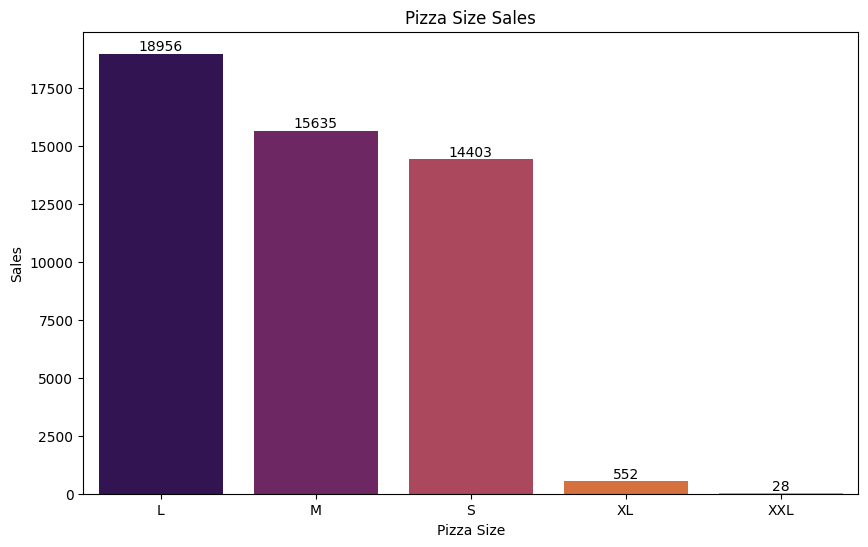

In [ ]:
plt.figure(figsize=(10,6))
a = sns.barplot(x=pizza_size.index,y=pizza_size.values,palette="inferno")
plt.title('Pizza Size Sales')
plt.xlabel('Pizza Size')
plt.ylabel('Sales')

for container in a.containers:
    a.bar_label(container)
plt.show()


Conclusion (Pizza Size Sales):

Large (L) pizzas have the highest sales (18,956), making them the most popular size among customers.

Medium (M) pizzas (15,635) and Small (S) pizzas (14,403) also show strong sales but are slightly lower than Large.

Extra Large (XL) pizzas (552) and XXL pizzas (28) have very low sales compared to other sizes.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
monthly_orders = df.groupby(df['order_date'].dt.to_period('M'))['order_id'].count()
monthly_orders

,order_id
order_date,
2015-01,4156
2015-02,3892
2015-03,4186
2015-04,4067
2015-05,4239
2015-06,4025
2015-07,4301
2015-08,4094
2015-09,3819


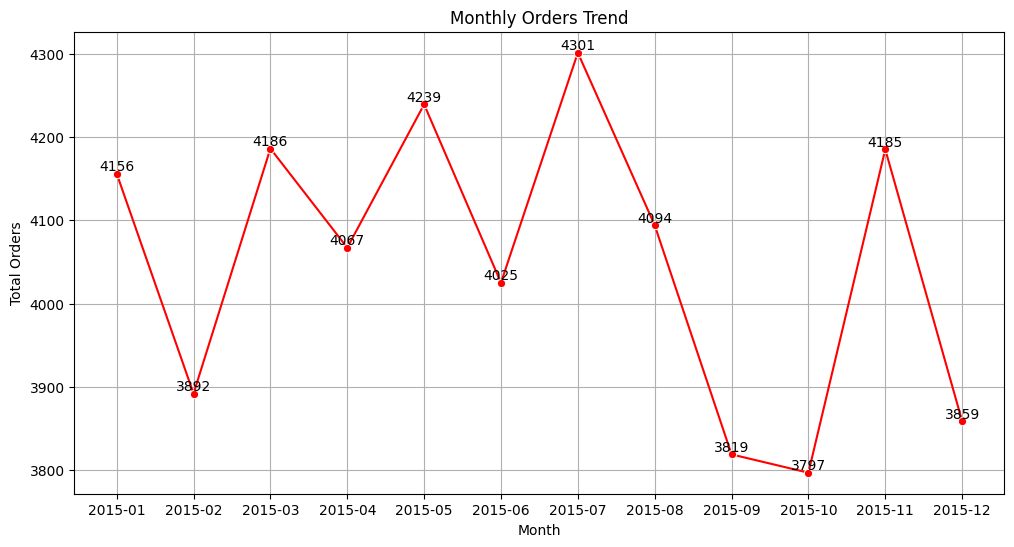

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(x=monthly_orders.index.astype(str), y=monthly_orders.values, marker="o", color="red")

for i, v in enumerate(monthly_orders.values):
    ax.text(i, v, v, ha="center", va="bottom")

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.grid(True)

plt.show()

Conclusion (Monthly Orders Trend):

The number of orders changes throughout the year and does not remain constant.

July has the highest number of orders (4301), showing the peak demand during the year.

October has the lowest number of orders (3797), indicating a drop in customer demand.

After October, orders increase again in November, but slightly decrease in December.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_revenue = df.groupby(df['order_date'].dt.month)['total_price'].sum()



In [ ]:
july_data = df[df['order_date'].dt.month == 7]


In [ ]:
july_pizza_sales = july_data.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False)
july_pizza_sales

,quantity
pizza_name,
The Classic Deluxe Pizza,227
The Pepperoni Pizza,224
The Thai Chicken Pizza,221
The Barbecue Chicken Pizza,219
The Hawaiian Pizza,195
The Spicy Italian Pizza,193
The California Chicken Pizza,187
The Big Meat Pizza,185
The Southwest Chicken Pizza,178


/tmp/ipykernel_312/2627889627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=july_pizza_sales.index, y=july_pizza_sales.values, palette="rocket")


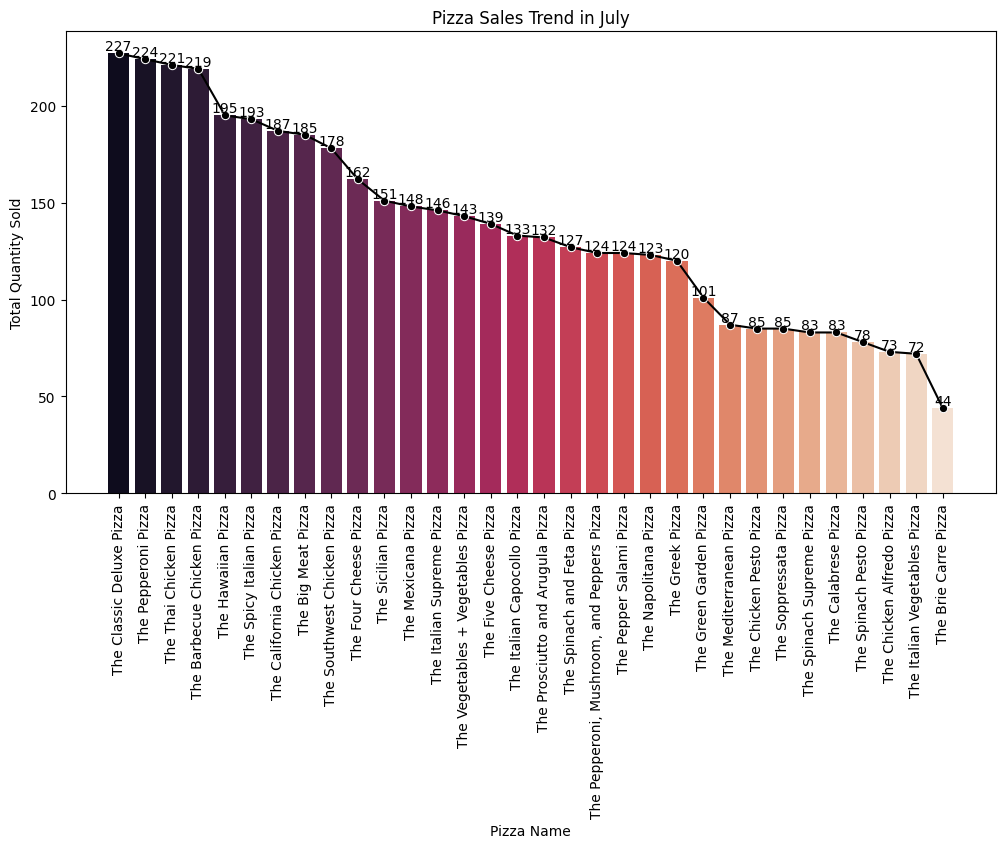

In [ ]:
plt.figure(figsize=(12,6))

# Bar graph
sns.barplot(x=july_pizza_sales.index, y=july_pizza_sales.values, palette="rocket")

# Trend line
sns.lineplot(x=july_pizza_sales.index, y=july_pizza_sales.values, color="black", marker="o")

plt.xticks(rotation=90)
plt.title("Pizza Sales Trend in July")
plt.xlabel("Pizza Name")
plt.ylabel("Total Quantity Sold")

for i, v in enumerate(july_pizza_sales.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

Conclusion (Pizza Sales Trend in July):

Some pizzas have significantly higher sales compared to others in July.

Classic Deluxe Pizza and Pepperoni Pizza are among the top-selling pizzas during this month.

Many pizzas show moderate sales levels, indicating consistent customer demand.

A few pizzas at the end of the chart have very low sales, meaning they are less popular among customers.

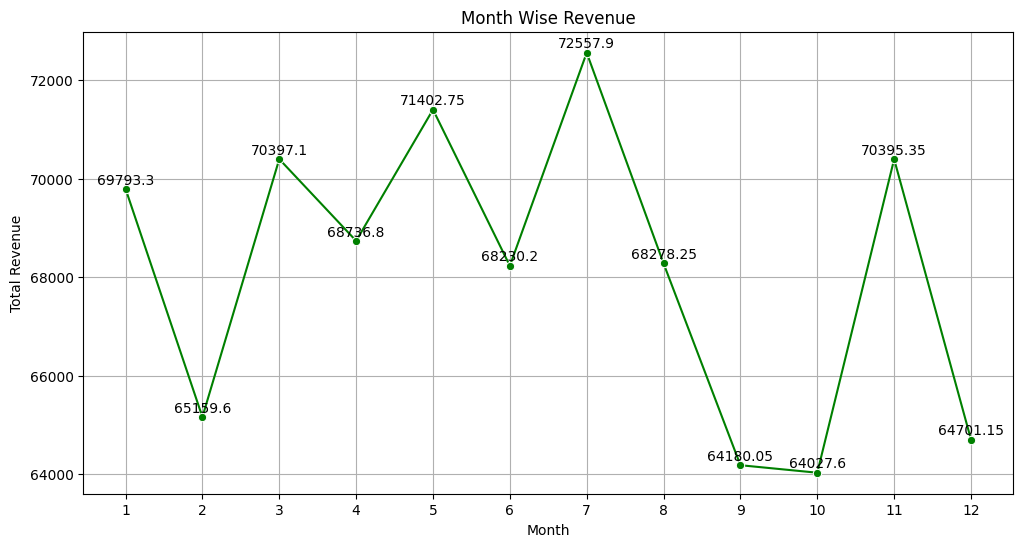

In [ ]:
plt.figure(figsize=(12,6))

ax = sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o",color= 'green')

for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    ax.text(x, y + 100, round(y,2), ha='center')

plt.title("Month Wise Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(range(1,13))

plt.grid(True)
plt.show()

Conclusion (Month Wise Revenue):

Revenue changes across different months and does not remain constant.

July has the highest revenue (~72,558), showing the peak performance during the year.

October has the lowest revenue (~64,028), indicating a decline in that period.

After October, revenue increases again in November, but slightly drops in December.

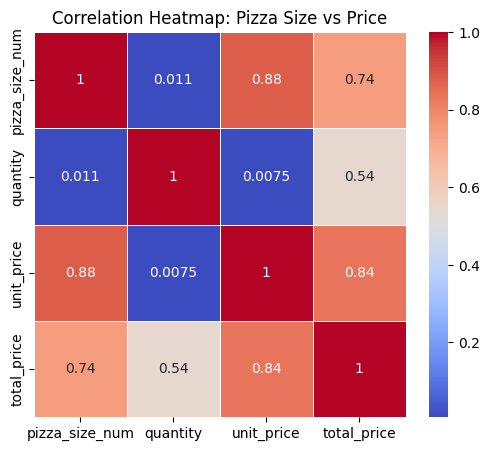

In [ ]:

size_map = {'S':1, 'M':2, 'L':3, 'XL':4, 'XXL':5}
df['pizza_size_num'] = df['pizza_size'].map(size_map)


data = df[['pizza_size_num','quantity','unit_price','total_price']]

corr = data.corr()


plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap: Pizza Size vs Price")
plt.show()

The heatmap shows a positive correlation between pizza size and price, indicating that larger pizzas have higher unit prices and generate higher total revenue. Quantity also has a strong positive relationship with total price, meaning larger orders increase overall sales revenue.